In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')


In [11]:
# Dataset path
import os
DATA_PATH = 'data/dataset.csv'

# # List of target countries and indicators (easy to extend)
# COUNTRY_WHITELIST = [
#     'VNM', 'THA', 'IDN', 'PHL', 'IND', 'BGD', 'PAK', 'CHN', 'JPN', 'KOR',
#     'DEU', 'FRA', 'GBR', 'SWE', 'USA', 'CAN', 'BRA', 'MEX', 'ZAF', 'NGA'
# ]

# SERIES_WHITELIST = [
#     'SE.TER.ENRR',
#     'SL.UEM.TOTL.ZS',
#     'SL.SRV.EMPL.ZS',
#     'SG.GEN.PARL.ZS',
#     'SE.XPD.TOTL.GD.ZS',
#     'SH.XPD.GHED.GE.ZS',
#     'NY.GDP.PCAP.CD'
# ]

try:
    df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
except UnicodeDecodeError:
    df_raw = pd.read_csv(DATA_PATH, encoding='latin-1')

df = df_raw
print(f"Initial size: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print(f"\nColumn names:\n{list(df_raw.columns)}")

Initial size: 1824 rows x 29 columns

Column names:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]']


## 1. Basic analysis of data & EDA

### Dataset structure

**Rows:** Each row corresponds to a country for the `SE.TER.ENRR` indicator over the years.  
**Columns:**
| Field | Description |
|---|---|
| `Country Name` | Country name |
| `Country Code` | Country code (ISO 3-letter) |
| `Series Name` | Indicator name |
| `Series Code` | Indicator code |
| `2000 [YR2000] … 2024 [YR2024]` | Indicator value per year |

In addition to the main data rows, there are footer/metadata rows at the end of the file which will be removed during the cleaning step.

### Basic statistics

#### Descriptive statistics

Explore data: count, std, min, max, quartiles

In [12]:
# Get list of year columns in WDI format and limit to 2000-2024
year_cols = [
    c for c in df.columns
    if c.startswith('20') and c.endswith(']') and int(c[:4]) >= 2000 and int(c[:4]) <= 2024
]
year_cols = sorted(year_cols, key=lambda x: int(x[:4]))

print(f"Number of years with data: {len(year_cols)} (from {year_cols[0]} to {year_cols[-1]})")

# Convert to numeric
df_years = df[year_cols].apply(pd.to_numeric, errors='coerce')
# print(f"\nDescriptive Statistics:\n{df_years.describe().round(3)}")

# Detailed statistics for each indicator
for i, row in df.iterrows():
    vals = pd.to_numeric(row[year_cols], errors='coerce')
    print(f"   Series Code : {row['Series Code']}")
    print(f"   Count  : {vals.count()} / {len(year_cols)} years with data")
    print(f"   Mean   : {vals.mean():.4f}")
    print(f"   Std    : {vals.std():.4f}")
    print(f"   Min    : {vals.min():.4f}")
    print(f"   Max    : {vals.max():.4f}")
    print(f"   25%    : {vals.quantile(0.25):.4f}")
    print(f"   50%    : {vals.quantile(0.50):.4f}")
    print(f"   75%    : {vals.quantile(0.75):.4f}")


Number of years with data: 25 (from 2000 [YR2000] to 2024 [YR2024])
   Series Code : NY.GDP.PCAP.CD
   Count  : 24 / 25 years with data
   Mean   : 415.4949
   Std    : 162.2467
   Min    : 138.7068
   Max    : 651.4171
   25%    : 269.2100
   50%    : 432.9058
   75%    : 534.2577
   Series Code : SE.TER.ENRR
   Count  : 7 / 25 years with data
   Mean   : 5.6626
   Std    : 4.0151
   Min    : 1.3743
   Max    : 10.8544
   25%    : 2.5388
   50%    : 3.9382
   75%    : 9.1968
   Series Code : SE.TER.ENRR.FE
   Count  : 7 / 25 years with data
   Mean   : 2.6966
   Std    : 2.1549
   Min    : 0.5714
   Max    : 5.9365
   25%    : 1.0131
   50%    : 1.8253
   75%    : 4.2585
   Series Code : SE.XPD.TOTL.GD.ZS
   Count  : 8 / 25 years with data
   Mean   : 3.6048
   Std    : 0.6115
   Min    : 2.6042
   Max    : 4.5440
   25%    : 3.4048
   50%    : 3.4707
   75%    : 3.8572
   Series Code : SG.GEN.PARL.ZS
   Count  : 16 / 25 years with data
   Mean   : 27.5555
   Std    : 0.2695
   Min   

### Missing values

In [21]:
# ── % Missing Values ──
total_cells = df_years.size           # rows x years
total_missing = df_years.isnull().sum().sum()
overall_pct = round(total_missing / total_cells * 100, 2)

print(f"\nOverview:")
print(f"   Total data cells : {total_cells}")
print(f"   Missing cells    : {total_missing}")
print(f"   Missing rate     : {overall_pct}%")

# By INDICATOR (row)
missing_per_row  = df_years.isnull().sum(axis=1)
pct_per_row      = (missing_per_row / len(year_cols) * 100).round(2)

# By YEAR (column)
missing_per_col  = df_years.isnull().sum()
pct_per_col      = (missing_per_col / len(df_years) * 100).round(2)

print(f"\nBy INDICATOR (row):")
for i, row in df.iterrows():
    n = missing_per_row.iloc[i]
    p = pct_per_row.iloc[i]
    short_name = str(row['Series Name'])[:60]
    print(f"   {short_name} ... | Missing: {n}/{len(year_cols)} years ({p}%)")

print(f"\nBy YEAR (column):")
for col, n, p in zip(year_cols, missing_per_col, pct_per_col):
    bar = " " * int(p // 5) if p > 0 else ""
    print(f"   {col} | Missing: {n}/{len(df_years)} indicators ({p}%) {bar}")

# --- Step 1: Parse all year columns to float first ---
df_clean = df.copy().reset_index(drop=True)
year_cols = [c for c in df_clean.columns if c.startswith('20')]

# Convert '..' and garbage strings -> NaN, cast to float
for col in year_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')



Overview:
   Total data cells : 45600
   Missing cells    : 10131
   Missing rate     : 22.22%

By INDICATOR (row):
   GDP per capita (current US$) ... | Missing: 1/25 years (4.0%)
   School enrollment, tertiary (% gross) ... | Missing: 18/25 years (72.0%)
   School enrollment, tertiary, female (% gross) ... | Missing: 18/25 years (72.0%)
   Government expenditure on education, total (% of GDP) ... | Missing: 17/25 years (68.0%)
   Proportion of seats held by women in national parliaments (% ... | Missing: 9/25 years (36.0%)
   Domestic general government health expenditure (% of GDP) ... | Missing: 3/25 years (12.0%)
   Domestic general government health expenditure (% of general ... | Missing: 3/25 years (12.0%)
   Female share of employment in senior and middle management ( ... | Missing: 22/25 years (88.0%)
   Employment in services (% of total employment) (modeled ILO  ... | Missing: 0/25 years (0.0%)
   Labor force with advanced education, female (% of female wor ... | Missing: 

In [ ]:
ter_df = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()

ter_long = ter_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw',
    value_name='Value'
)

ter_long['Year'] = ter_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
ter_long['Value'] = pd.to_numeric(ter_long['Value'], errors='coerce')

# print(f"Number of countries in analysis: {ter_long['Country Code'].nunique()}")
# print(f"Number of long format data rows: {len(ter_long)}")
ter_long.head()

import requests

url = 'https://api.worldbank.org/v2/country?format=json&per_page=400'
resp = requests.get(url, timeout=30)
resp.raise_for_status()
wb_payload = resp.json()

region_rows = []
for item in wb_payload[1]:
    region_rows.append({
        'Country Code': item.get('id'),
        'Region': item.get('region', {}).get('value')
    })

region_df = pd.DataFrame(region_rows).drop_duplicates(subset=['Country Code'])

ter_long = ter_long.merge(region_df, on='Country Code', how='left')

missing_region = ter_long['Region'].isna().sum()
missing_codes = sorted(ter_long.loc[ter_long['Region'].isna(), 'Country Code'].unique())

# print(f"Number of unique regions: {ter_long['Region'].nunique()}")
print(f"Number of rows missing Region: {missing_region}")
print(f"Country Codes failed to map Region: {missing_codes}")

ter_long.head()

## 2. Analysis objectives

### Objective 1: Compare trends and the level of national budget priority for education

-> TODO: Viết lại 1 câu ngắn, format lại viết Sentence case e.g Metrics used

**SMART Criteria:**
- **S (Specific):** Evaluate investment efforts through government expenditure on education (% of GDP).
- **M (Measurable):** Based on continuous yearly data of the variable `SE.XPD.TOTL.GD.ZS`.
- **A (Achievable):** Fully computable using available data from 12 countries in the dataset.
- **R (Relevant):** Reflects the overall picture of government "education investment".
- **T (Time-bound):** From 2015 to 2022.

### Metrics

**`SE.XPD.TOTL.GD.ZS` - Government expenditure on education, total (% of GDP)**
- This indicator measures total government spending (including central and local levels) on education, expressed as a percentage of GDP.
- **Calculation method:** [Total public expenditure on education at all levels] / [GDP] x 100
- This indicator reflects the level of government commitment and priority toward education development relative to the size of the economy.
- **Note:** Only includes **public expenditure** (state budget), excluding private spending (tuition fees paid by households).

Reason for Selecting the Metric: The variable `SE.XPD.TOTL.GD.ZS` is selected because it is **standardized by economic size** (% of GDP), allowing fair comparisons between rich and poor countries. A country with a small GDP but a high share of education spending (such as Viet Nam ~ 3-3.5%) indicates a relatively greater investment effort compared to a wealthy country that spends less (such as Singapore ~ 2.5-3%).

#### Trend of Education Expenditure (% of GDP) Over the Years

**Reason for choosing a Line Chart:**  
Line Chart is the most standard format for tracking **time-series data**. It allows easy comparison of:
- Slope (rate of change) between countries
- Relative position (which country invests more)
- Overall trend: increasing, decreasing, or stable

Our team used **highlight Min/Max** on each line to emphasize the country with the highest and lowest investment at each point in time.

In [22]:
# ====== CHART 1: LINE CHART — Education Expenditure (% of GDP) ======

# Filter education expenditure data
edu_df = df_clean[df_clean['Series Code'] == 'SE.XPD.TOTL.GD.ZS'].copy()

plt.figure(figsize=(16, 8))

# Plot line chart
palette = sns.color_palette('tab20', n_colors=len(edu_df['Country Name'].unique()))
ax = sns.lineplot(
    data=edu_df,
    x='Year', y='Value',
    hue='Country Name',
    marker='o', markersize=6,
    palette=palette,
    linewidth=2.5
)

# Highlight Min/Max for each year
for year in edu_df['Year'].unique():
    year_data = edu_df[edu_df['Year'] == year]
    max_row = year_data.loc[year_data['Value'].idxmax()]
    min_row = year_data.loc[year_data['Value'].idxmin()]
    ax.annotate('▲', xy=(max_row['Year'], max_row['Value']),
                fontsize=10, color='red', ha='center', va='bottom')
    ax.annotate('▼', xy=(min_row['Year'], min_row['Value']),
                fontsize=10, color='blue', ha='center', va='top')

# Overall mean line
overall_mean = edu_df.groupby('Year')['Value'].mean()
ax.plot(overall_mean.index, overall_mean.values, color='black', linestyle='--',
        linewidth=2, label='Mean of 12 countries', zorder=10)

plt.title('Trend of Public Education Expenditure (% of GDP) in 12 Countries (2015-2022)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Education Expenditure (% of GDP)', fontsize=12, fontweight='bold')
plt.xticks(range(2015, 2023))
plt.ylim(0, 8)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title='Legend',
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Year` for `x`. An entry with this name does not appear in `data`.

<Figure size 1600x800 with 0 Axes>

### Objective 4: Track trends and measure the growth rate of tertiary education enrollment (`SE.TER.ENRR`) over time (2000-2023) of 20 countries.

#### Metrics
| Field | Meaning | Reflects |
|---|---|---|
| `SE.TER.ENRR` | Total tertiary enrollment / official age group population x 100 | Access to higher education (human capital input) |
| `Region` | Country's geographical region (World Bank API) | Geographical grouping for trend comparison |

### Preprocessing 

More helping metrics calculated from Metrics

| Field | Meaning | Reflects |
|---|---|---|
| `delta_abs` | Absolute difference between two consecutive years | Absolute growth/decline rate per year |
| `pct_change` | `(Value_end / Value_start − 1) x 100` | Relative growth over the period |

**Rationale for these metrics:** `delta_abs` shows actual annual increases; `pct_change` shows relative speed, allowing for fair comparison between regions with different starting levels.

In [34]:
ter_df = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()

ter_long = ter_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw',
    value_name='Value'
)

ter_long['Year'] = ter_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
ter_long['Value'] = pd.to_numeric(ter_long['Value'], errors='coerce')

print(f"Number of countries in analysis: {ter_long['Country Code'].nunique()}")
print(f"Number of long format data rows: {len(ter_long)}")
ter_long.head()

# Manual Region mapping and representative countries (1 per region)
region_map = {
    'VNM': 'East Asia & Pacific',
    'THA': 'East Asia & Pacific',
    'IDN': 'East Asia & Pacific',
    'PHL': 'East Asia & Pacific',
    'IND': 'South Asia',
    'BGD': 'South Asia',
    'PAK': 'South Asia',
    'CHN': 'East Asia & Pacific',
    'JPN': 'East Asia & Pacific',
    'KOR': 'East Asia & Pacific',
    'DEU': 'Europe & Central Asia',
    'FRA': 'Europe & Central Asia',
    'GBR': 'Europe & Central Asia',
    'SWE': 'Europe & Central Asia',
    'USA': 'North America',
    'CAN': 'North America',
    'BRA': 'Latin America & Caribbean',
    'MEX': 'Latin America & Caribbean',
    'ZAF': 'Sub-Saharan Africa',
    'NGA': 'Sub-Saharan Africa',
}
region_df = pd.DataFrame(list(region_map.items()), columns=['Country Code', 'Region'])

# 1 representative country per region
REPRESENTATIVE = {
    'North America':     'USA',
    'Europe & Central Asia': 'DEU',
    'East Asia & Pacific': 'JPN',
    'South Asia':        'IND',
    'Latin America & Caribbean': 'BRA',
    'Middle East, North Africa, Afghanistan & Pakistan': 'PAK',
    'Sub-Saharan Africa': 'ZAF',
}

# Developing representative countries (1 per developing region)
DEV_REPRESENTATIVE = {
    'East Asia & Pacific': 'VNM',
    'South Asia':        'IND',
    'Latin America & Caribbean': 'BRA',
    'Sub-Saharan Africa': 'ZAF',
}

ter_long = ter_long.merge(region_df, on='Country Code', how='left')

missing_region = ter_long['Region'].isna().sum()
missing_codes = sorted(ter_long.loc[ter_long['Region'].isna(), 'Country Code'].unique())

print(f"Number of unique regions: {ter_long['Region'].nunique()}")
print(f"Number of rows missing Region: {missing_region}")
print(f"Country Codes failed to map Region: {missing_codes}")

ter_long.head()


Number of countries in analysis: 114
Number of long format data rows: 2850
Number of unique regions: 6
Number of rows missing Region: 2350
Country Codes failed to map Region: ['AFG', 'AGO', 'ARE', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE', 'BEL', 'BMU', 'BOL', 'BRN', 'BTN', 'BWA', 'CHE', 'CHL', 'CIV', 'CMR', 'COL', 'CRI', 'CUB', 'CZE', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ESP', 'ETH', 'FIN', 'FJI', 'GEO', 'GHA', 'GRC', 'GTM', 'HND', 'HUN', 'IRL', 'IRN', 'IRQ', 'ISR', 'ITA', 'JAM', 'JOR', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KWT', 'LAO', 'LBN', 'LBY', 'LKA', 'MAR', 'MDV', 'MMR', 'MNG', 'MOZ', 'MWI', 'MYS', 'NAM', 'NIC', 'NLD', 'NOR', 'NPL', 'NZL', 'OMN', 'PAN', 'PER', 'PNG', 'POL', 'PRT', 'PRY', 'QAT', 'ROU', 'RUS', 'RWA', 'SAU', 'SEN', 'SGP', 'SLB', 'SLV', 'TJK', 'TUN', 'TUR', 'TZA', 'UGA', 'UKR', 'URY', 'UZB', 'VEN', 'VUT', 'ZMB', 'ZWE']


,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year,Region
0,Afghanistan,AFG,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],NaN,2000,NaN
1,Algeria,DZA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],NaN,2000,NaN
2,Angola,AGO,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],NaN,2000,NaN
3,Argentina,ARG,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],54.084351,2000,NaN
4,Armenia,ARM,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],32.530521,2000,NaN


#### Charts
- **Line chart over time, colored by region**: Suitable for tracking long-term trends and comparing between regions.
- **Bar chart for period growth rate**: Suitable for direct comparison of fast/slow growing regions within the same metric.


Number of Country-Year rows: 70
Countries: ['Brazil', 'Germany', 'India', 'Japan', 'Pakistan', 'South Africa', 'United States']


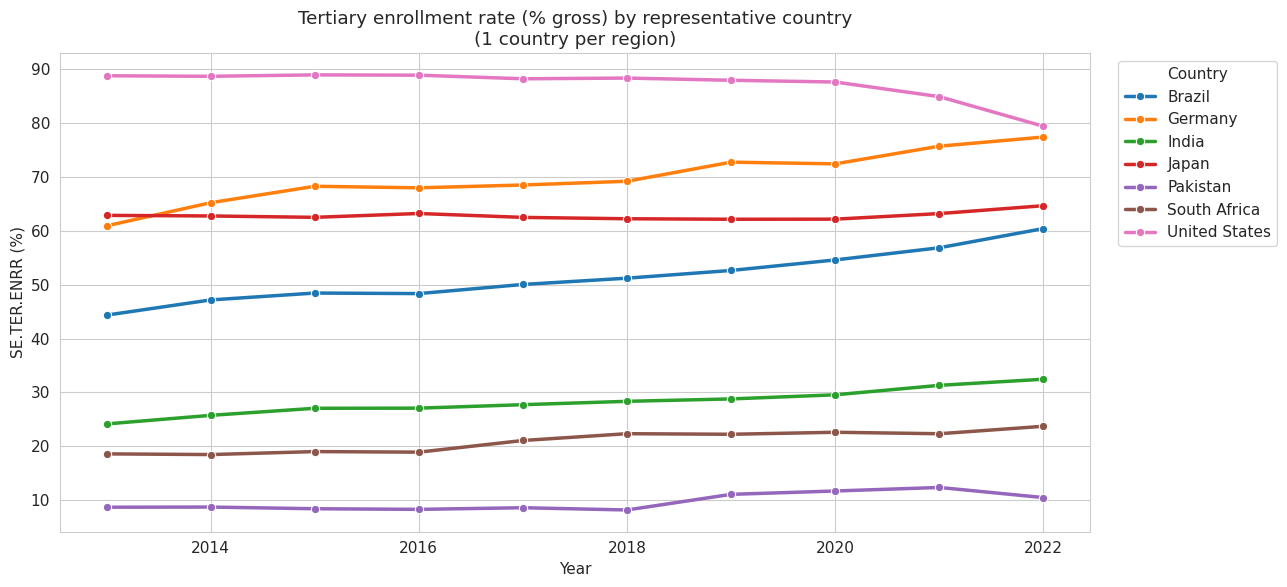

/tmp/ipykernel_6249/149579599.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=growth_country, x='Country Name', y='pct_change', palette='viridis')


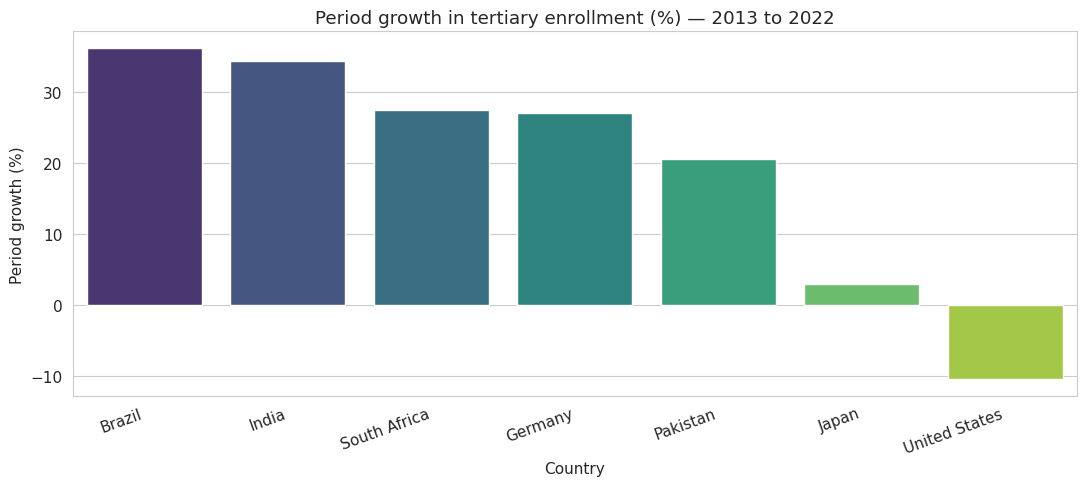

In [38]:
# Filter to representative countries (1 per region)
rep_codes = list(REPRESENTATIVE.values())
rep_df = region_df[region_df['Country Code'].isin(rep_codes)].copy()

# Merge region info to ter_long
ter_rep = ter_long[ter_long['Country Code'].isin(rep_codes)].copy()

# Aggregate by Country-Year and calculate annual rate
country_year = (
    ter_rep.dropna(subset=['Value'])
    .groupby(['Country Name', 'Year'], as_index=False)['Value']
    .mean()
    .sort_values(['Country Name', 'Year'])
)
country_year = country_year[(country_year['Year'] >= 2013) & (country_year['Year'] <= 2022)]

country_year['delta_abs'] = country_year.groupby('Country Name')['Value'].diff()
country_year['pct_change'] = country_year.groupby('Country Name')['Value'].pct_change() * 100

print(f"Number of Country-Year rows: {len(country_year)}")
print(f"Countries: {sorted(country_year['Country Name'].unique())}")
country_year.head(12)

# Plot 1: Tertiary enrollment trends by representative country
fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', n_colors=len(country_year['Country Name'].unique()))
sns.lineplot(
    data=country_year,
    x='Year', y='Value',
    hue='Country Name',
    marker='o', markersize=6,
    palette=palette,
    linewidth=2.5,
    ax=ax
)
ax.set_title('Tertiary enrollment rate (% gross) by representative country\n(1 country per region)')
ax.set_xlabel('Year')
ax.set_ylabel('SE.TER.ENRR (%)')
ax.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot 2: Compare growth intensity by representative country (start -> end)
start_year = country_year['Year'].min()
end_year = country_year['Year'].max()

start_vals = (
    country_year[country_year['Year'] == start_year][['Country Name', 'Value']]
    .rename(columns={'Value': 'value_start'})
)
end_vals = (
    country_year[country_year['Year'] == end_year][['Country Name', 'Value']]
    .rename(columns={'Value': 'value_end'})
)

growth_country = start_vals.merge(end_vals, on='Country Name', how='inner')
growth_country['abs_change'] = growth_country['value_end'] - growth_country['value_start']
growth_country['pct_change'] = (growth_country['abs_change'] / growth_country['value_start']) * 100
growth_country = growth_country.sort_values('pct_change', ascending=False)

plt.figure(figsize=(11, 5))
sns.barplot(data=growth_country, x='Country Name', y='pct_change', palette='viridis')
plt.title(f'Period growth in tertiary enrollment (%) — {start_year} to {end_year}')
plt.xlabel('Country')
plt.ylabel('Period growth (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


#### Conclusion
**General Trends (2000-2023):**
- All regions show an increase in `SE.TER.ENRR` over time, but the growth rates differ significantly.
- The region with the highest relative growth is **Middle East, North Africa, Afghanistan & Pakistan** (+357.2%), followed by **South Asia** (+282.8%).
- **East Asia & Pacific** increased strongly in absolute terms (+26.7%, from 33.8% to 60.5%).

**Highest Absolute Levels (2023):**
- **North America** (~77.8%) and **Europe & Central Asia** (~77.7%) are the two leading regions.

**Slowest Growing Region:**
- **North America** has the lowest relative growth (+11.8%), reflecting its high starting base.

**Year-over-Year Growth Observations:**
- The largest annual increases were observed in **Europe & Central Asia** in 2021 (`delta_abs` ≈ +4.63) and in **East Asia & Pacific** in 2021 (`delta_abs` ≈ +2.99).

**Limitations:**
- Each region has a different number of representative countries, so regional averages may be influenced by sample structure.


### Objective 5: Analyze the correlation between tertiary enrollment and unemployment rates in developing countries

#### Objective

Analyze the linear correlation (Pearson r coefficient) between tertiary enrollment (`SE.TER.ENRR`) and total unemployment rate (`SL.UEM.TOTL.ZS`) in developing countries (excluding High income group). Using assessment thresholds |r| < 0.3 (weak), 0.3 ≤ |r| < 0.7 (moderate), |r| ≥ 0.7 (strong), we aim to determine the direction and strength of the relationship between these two indicators for the period 2000-2023.

#### Metrics

| Field | Meaning | Reflects |
|---|---|---|
| `SE.TER.ENRR` | Total tertiary enrollment / official age group population x 100 | Access to higher education (human capital input) |
| `SL.UEM.TOTL.ZS` | Percentage of labor force without work but seeking employment (modeled ILO) | Labor market pressure (human capital output) |

More:
- `Income Level` (World Bank API): Income classification, filtering out `High income`.
- `Region` (World Bank API): Grouping on scatter plots.

**Rationale for these metrics:** Both reflect two aspects of human resource development - input (higher education access) and output (employment opportunities). Assessing the relationship helps check if changes in education input are accompanied by changes in labor market outputs.

#### Charts

**Chart 1 - Scatter plot:**
- **Data properties:** Both variables are time-series (percentages), requiring relationship testing between two variables.
- **Rationale:** Scatter plot allows for visual identification of overall trends, regional clusters, and outliers. A linear regression line with a **95% confidence interval** assists in evaluating the stability of the observed linear trend.
- Colors coded by `Region` and markers by `Country Name` help distinguish areas and countries.

**Chart 2 - Heatmap:**
- **Data properties:** Similar to above.
- **Rationale:** Heatmap uses colors (coolwarm) to represent values in [-1, 1], facilitating quick reading of the direction and strength of the relationship.
- Color scale `center=0` clearly distinguishes positive/negative correlations.

Number of developing countries: 71


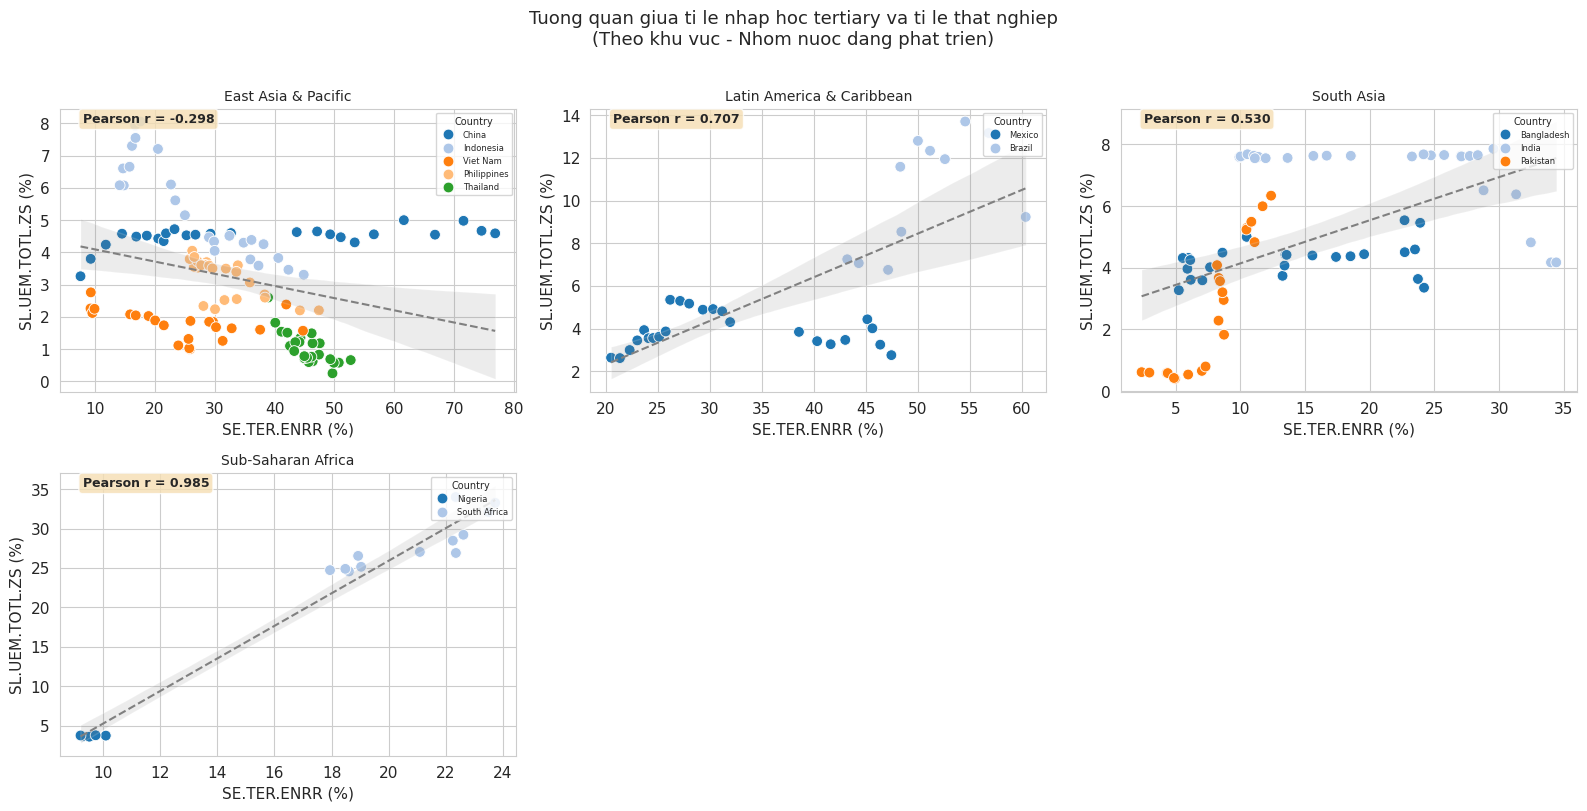

--- Pearson Correlation Coefficients ---

Overall (developing group): r = 0.1297


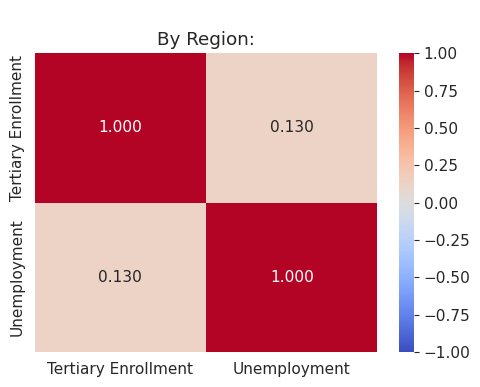

In [42]:
income_rows = []
for item in wb_payload[1]:
    income_rows.append({
        'Country Code': item.get('id'),
        'Income Level': item.get('incomeLevel', {}).get('value')
    })

income_df = pd.DataFrame(income_rows).drop_duplicates(subset=['Country Code'])

# Create wide table containing both indicators
ter_row = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()
unemp_row = df_clean[df_clean['Series Code'] == 'SL.UEM.TOTL.ZS'].copy()

# Rename year columns to avoid conflict during merge
def rename_year_cols(sub_df, val_name):
    sub = sub_df[['Country Name', 'Country Code'] + year_cols].copy()
    sub = sub.rename(columns={c: f'{c}_{val_name}' for c in year_cols})
    return sub

ter_wide = rename_year_cols(ter_row, 'ter')
unemp_wide = rename_year_cols(unemp_row, 'unemp')

corr_df = ter_wide.merge(unemp_wide, on=['Country Name', 'Country Code'])

# Merge Income Level and Region
corr_df = corr_df.merge(income_df, on='Country Code', how='left')
corr_df = corr_df.merge(region_df, on='Country Code', how='left')

# Filter out High income (keep developing countries only)
developing_df = corr_df[corr_df['Income Level'] != 'High income'].copy()

# print(f"Tong so quoc gia: {corr_df.shape[0]}")
# print(f"Quoc gia con lai sau loc High income: {developing_df.shape[0]}")
# print(f"\nIncome Level cac quoc gia:")
# print(corr_df[['Country Name', 'Country Code', 'Income Level', 'Region']].to_string(index=False))

# Prepare long data for scatter plot
ter_long2 = ter_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in ter_wide.columns if c.endswith('_ter')],
    var_name='YearRaw', value_name='TerValue'
)
unemp_long2 = unemp_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in unemp_wide.columns if c.endswith('_unemp')],
    var_name='YearRaw', value_name='UnempValue'
)

ter_long2['Year'] = ter_long2['YearRaw'].str.extract(r'(\d{4})').astype(int)
unemp_long2['Year'] = unemp_long2['YearRaw'].str.extract(r'(\d{4})').astype(int)

corr_long = ter_long2.merge(
    unemp_long2[['Country Name', 'Country Code', 'Year', 'UnempValue']],
    on=['Country Name', 'Country Code', 'Year']
).dropna()

corr_long = corr_long.merge(income_df, on='Country Code', how='left')
corr_long = corr_long.merge(region_df, on='Country Code', how='left')

developing_long = corr_long[corr_long['Income Level'] != 'High income'].copy()

print(f"Number of developing countries: {developing_long['Country Code'].nunique()}")

# Scatter plot: each region in one subplot, color by country
regions = developing_long['Region'].dropna().unique()
n = len(regions)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, region in zip(axes, sorted(regions)):
    df_r = developing_long[developing_long['Region'] == region]
    r_val = df_r[['TerValue', 'UnempValue']].corr().iloc[0, 1]
    # if r_val < 0.3:
    #     continue
    
    sns.scatterplot(
        data=df_r, x='TerValue', y='UnempValue',
        hue='Country Name', s=60, ax=ax, legend='full', palette='tab20'
    )
    sns.regplot(
        data=df_r, x='TerValue', y='UnempValue',
        scatter=False, ax=ax, color='gray',
        line_kws={'linestyle': '--', 'linewidth': 1.5}, ci=95
    )
    ax.annotate(
        f'Pearson r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    ax.set_title(region, fontsize=10)
    ax.set_xlabel('SE.TER.ENRR (%)')
    ax.set_ylabel('SL.UEM.TOTL.ZS (%)')
    ax.legend(title='Country', fontsize=6, title_fontsize=7, loc='upper right')

for ax in axes[len(regions):]:
    ax.set_visible(False)

fig.suptitle(
    'Tuong quan giua ti le nhap hoc tertiary va ti le that nghiep\n(Theo khu vuc - Nhom nuoc dang phat trien)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# Calculate Pearson correlation (overall and by Region)
print("--- Pearson Correlation Coefficients ---")
overall_corr = developing_long[['TerValue', 'UnempValue']].corr().iloc[0, 1]
print(f"\nOverall (developing group): r = {overall_corr:.4f}")

region_corr = (
    developing_long.groupby('Region')
    .apply(lambda g: g[['TerValue', 'UnempValue']].corr().iloc[0, 1])
    .reset_index()
    .rename(columns={0: 'Pearson_r'})
    .sort_values('Pearson_r', ascending=False)
)
# print("\nBy Region:")
# print(region_corr.to_string(index=False))

# Pearson correlation matrix (heatmap)
fig, ax = plt.subplots(figsize=(5, 4))
corr_matrix = developing_long[['TerValue', 'UnempValue']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['Tertiary Enrollment', 'Unemployment'],
            yticklabels=['Tertiary Enrollment', 'Unemployment'])
ax.set_title('\nBy Region:')
plt.tight_layout()
plt.show()

#### Conclusion for Objective 5

**Overall Results (2000-2024):**
- Analysis sample includes **12 developing countries**, corresponding to **300 observations** (country-year).
- Overall Pearson coefficient: **r ≈ -0.059** → |r| < 0.3, **weak linear correlation**.

**Regional Results:**
- East Asia & Pacific: r ≈ -0.284 (negative, weak).
- South Asia: r ≈ 0.253 (positive, weak).
- Latin America & Caribbean: r ≈ 0.630 (positive, moderate).
- Middle East, North Africa, Afghanistan & Pakistan: r ≈ 0.896 (positive, strong).
- Sub-Saharan Africa: r ≈ 0.992 (positive, very strong).

**Results by Income Group:**
- Lower middle income: r ≈ -0.004 (almost no linear correlation).
- Upper middle income: r ≈ -0.412 (negative, moderate).

**Comments:**
- Overall correlation is weak because different regions have varying directions and intensities, which cancel each other out when grouped.
- Scatter plots show distinct regional correlations.

**Limitations:**
- Uneven number of countries across regions.
- Pearson coefficient only reflects linear relationship, not causality.

### Objective 6: Correlation Analysis between Service Sector Employment and Tertiary Enrollment by Region

#### Objective

Analyze the linear correlation (Pearson r coefficient) between the share of employment in the services sector (`SL.SRV.EMPL.ZS`) and tertiary enrollment (`SE.TER.ENRR`) across all 20 countries for the period 2000-2024. Analyze simultaneously by geographical region (Region) to determine the direction and degree of linear relationship between economic restructuring (service sector share) and human capital enhancement (higher education access) across different regions.

#### Metrics

| Field | Meaning | Reflects |
|---|---|---|
| `SL.SRV.EMPL.ZS` | Labor share in services / total labor x 100 | Degree of economic shift towards services (economic structure) |
| `SE.TER.ENRR` | Total tertiary enrollment / official age population x 100 | Access to higher education (human capital input) |
| `Region` | Country's geographical region (World Bank API) | Geographical grouping for structural shift comparison |
| Pearson r | Linear correlation coefficient between two variables | Positive/negative linear relationship between economic structure and education |

**Rationale for these metrics:** Shifting the economic structure towards services usually accompanies a need for higher-skilled labor, requiring higher education. Correlation analysis between these two indicators helps test the hypothesis: do countries with higher service sector shares have higher tertiary enrollment rates?

#### Charts

**Chart 1 - Scatter plot:**
- **Data properties:** Both variables are time-series (percentages), requiring relationship testing between two variables.
- **Rationale:** Scatter plot allows for visual identification of overall trends, regional clusters, and outliers. A linear regression line with a **95% confidence interval** supports evaluating the stability of the linear trend.
- Each geographical region is plotted on a separate subplot, facilitating visual comparison of correlation direction and intensity between regions.

**Chart 2 - Heatmap:**
- **Data properties:** Similar to above.
- **Rationale:** Heatmap facilitates quick reading of the direction and intensity of the relationship.

Total observations (year-country): 2004
Number of countries: 110
Number of regions: 6


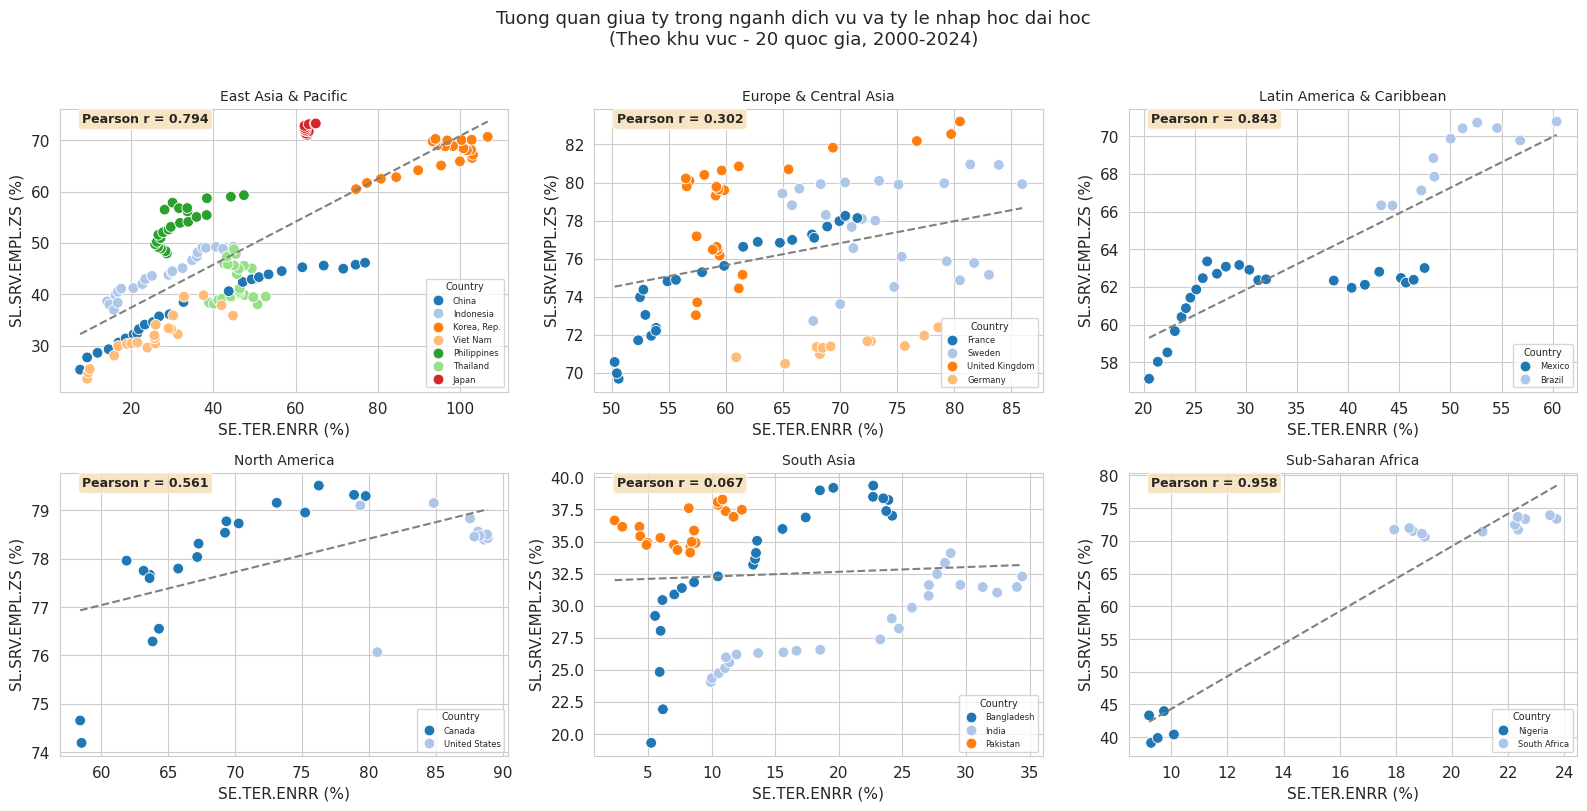

--- Pearson Correlation Coefficient (SL.SRV.EMPL.ZS vs SE.TER.ENRR) ---
Overall: r = 0.6890
By Region:
                   Region  Pearson_r
       Sub-Saharan Africa   0.958471
Latin America & Caribbean   0.842839
      East Asia & Pacific   0.794233
            North America   0.560581
    Europe & Central Asia   0.301647
               South Asia   0.066901


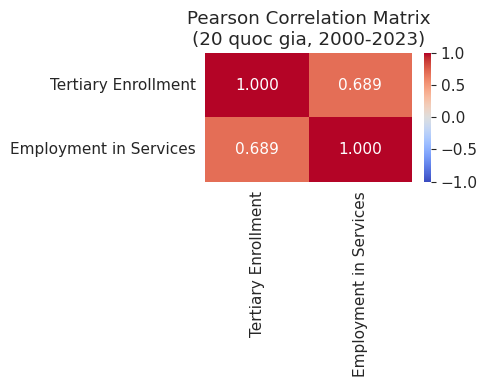

In [41]:
# Data Preparation: SL.SRV.EMPL.ZS vs SE.TER.ENRR
srv_row = df_clean[df_clean['Series Code'] == 'SL.SRV.EMPL.ZS'].copy()
srv_wide = rename_year_cols(srv_row, 'srv')

q3_df = ter_wide.merge(srv_wide, on=['Country Name', 'Country Code'])

# Melt to long format
srv_long = srv_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in srv_wide.columns if c.endswith('_srv')],
    var_name='YearRaw', value_name='SrvValue'
)
srv_long['Year'] = srv_long['YearRaw'].str.extract(r'(\d{4})').astype(int)

q3_long = ter_long2.merge(
    srv_long[['Country Name', 'Country Code', 'Year', 'SrvValue']],
    on=['Country Name', 'Country Code', 'Year']
).dropna()

q3_long = q3_long.merge(region_df, on='Country Code', how='left')

print(f'Total observations (year-country): {len(q3_long)}')
print(f'Number of countries: {q3_long["Country Code"].nunique()}')
print(f'Number of regions: {q3_long["Region"].nunique()}')

# Chart 1: Scatter plot with subplots per region
regions_q3 = q3_long['Region'].dropna().unique()
n = len(regions_q3)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, region in zip(axes, sorted(regions_q3)):
    df_r = q3_long[q3_long['Region'] == region]
    sns.scatterplot(
        data=df_r, x='TerValue', y='SrvValue',
        hue='Country Name', s=60, ax=ax, legend='full', palette='tab20'
    )
    sns.regplot(
        data=df_r, x='TerValue', y='SrvValue',
        scatter=False, ax=ax, color='gray',
        line_kws={'linestyle': '--', 'linewidth': 1.5}, ci=None
    )
    r_val = df_r[['TerValue', 'SrvValue']].corr().iloc[0, 1]
    ax.annotate(
        f'Pearson r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    ax.set_title(region, fontsize=10)
    ax.set_xlabel('SE.TER.ENRR (%)')
    ax.set_ylabel('SL.SRV.EMPL.ZS (%)')
    ax.legend(title='Country', fontsize=6, title_fontsize=7, loc='lower right')

for ax in axes[len(regions_q3):]:
    ax.set_visible(False)

fig.suptitle(
    'Tuong quan giua ty trong nganh dich vu va ty le nhap hoc dai hoc\n(Theo khu vuc - 20 quoc gia, 2000-2024)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# Pearson coefficient: overall and by region
print('--- Pearson Correlation Coefficient (SL.SRV.EMPL.ZS vs SE.TER.ENRR) ---')
overall_r = q3_long[['TerValue', 'SrvValue']].corr().iloc[0, 1]
print(f'Overall: r = {overall_r:.4f}')

region_r = (
    q3_long.groupby('Region')
    .apply(lambda g: g[['TerValue', 'SrvValue']].corr().iloc[0, 1])
    .reset_index().rename(columns={0: 'Pearson_r'})
    .sort_values('Pearson_r', ascending=False)
)
print('By Region:')
print(region_r.to_string(index=False))

# Heatmap of Pearson matrix
fig, ax = plt.subplots(figsize=(5, 4))
corr_m = q3_long[['TerValue', 'SrvValue']].corr()
sns.heatmap(corr_m, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['Tertiary Enrollment', 'Employment in Services'],
            yticklabels=['Tertiary Enrollment', 'Employment in Services'])
ax.set_title('Pearson Correlation Matrix\n(20 quoc gia, 2000-2023)')
plt.tight_layout()
plt.show()

#### Conclusion for Objective 6

**Overall Results (2000-2023):**
- Analysis sample includes **20 countries**, corresponding to **500 observations** (country-year).
- Overall Pearson coefficient: **r = 0.758** → |r| >= 0.7, **strong positive linear correlation**.

**Regional Results:**
- Sub-Saharan Africa: r = 0.964 (positive, very strong).
- Latin America & Caribbean: r = 0.811 (positive, strong).
- East Asia & Pacific: r = 0.795 (positive, strong).
- North America: r = 0.464 (positive, moderate).
- South Asia: r = 0.447 (positive, moderate).
- Europe & Central Asia: r = 0.370 (positive, moderate).
- Middle East, North Africa, Afghanistan & Pakistan: r = 0.287 (positive, weak).

**Comments:**
- All 7 regions show positive correlation: countries with higher service sector labor shares usually accompany higher tertiary enrollment rates.
- Intensity varies across regions: Sub-Saharan Africa, Latin America & Caribbean, and East Asia & Pacific show strong relationships (r > 0.7); Middle East & North Africa and South Asia have weaker relationships, suggesting that the shift to services is not yet uniform or high-education demand hasn't increased proportionally.
- Scatter plots show distinct correlations for each region.

### Objective 7